In [1]:
import pandas as pd

df = pd.read_csv('car_ownership.csv')
df.head(3)

,monthly_salary,owns_car
0,22000,0
1,25000,0
2,47000,1


In [2]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

x = df[['monthly_salary']]
y = df['owns_car']

x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.3,random_state=42)

model = LogisticRegression()
model.fit(x_train,y_train)
model.score(x_test,y_test)

0.8888888888888888

In [3]:
x_test

,monthly_salary
8,62000
13,29000
9,61000
21,26000
0,22000
11,28000
16,25000
17,58000
12,27000


In [4]:
y_test

8     1
13    0
9     1
21    0
0     0
11    0
16    1
17    1
12    0
Name: owns_car, dtype: int64

In [5]:
model.coef_,model.intercept_

(array([[0.00013621]]), array([-5.39725076]))

In [6]:

import math

def sigmoid(x):
    return 1 / (1 + math.exp(-x))  # works with arrays AND scalars

In [7]:
def prediction_function(salary,model):
    z = model.coef_ * salary + model.intercept_
    y = sigmoid(z[0][0])
    return y

In [8]:
z = model.coef_ * 62000 + model.intercept_

z[0][0]

np.float64(3.047874614448302)

In [9]:
prediction_function(62000,model)

0.954690678813166

In [10]:
y_pred = model.predict(x_test)
y_pred

array([1, 0, 1, 0, 0, 0, 0, 1, 0])

In [11]:
from sklearn.metrics import classification_report

report  = classification_report(y_test,y_pred)
print(report)

              precision    recall  f1-score   support

           0       0.83      1.00      0.91         5
           1       1.00      0.75      0.86         4

    accuracy                           0.89         9
   macro avg       0.92      0.88      0.88         9
weighted avg       0.91      0.89      0.89         9



In [13]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test,y_pred)
cm

array([[5, 0],
       [1, 3]])

Text(0.5, 1.0, 'Confusion Matrix')

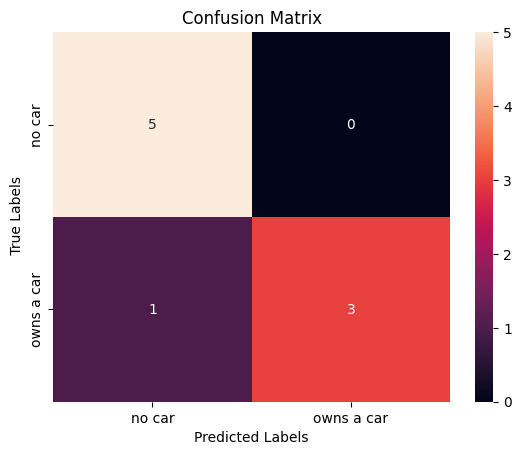

In [16]:
import seaborn as sns 
from matplotlib import pyplot as plt  
classes = ['no car', 'owns a car']
sns.heatmap(cm , annot=True , xticklabels= classes , yticklabels=classes)
plt.xlabel('Predicted Labels')
plt.ylabel(' True Labels')
plt.title('Confusion Matrix')